# Three-Label Model Comparisons

This notebook compares four configurations for a 3-label SFH setup:

- log no prior (`log-model`)
- log with prior (`log-prior-model`)
- linear bounds no prior (`linear-model`)
- linear bounds with prior (`linear-bounds-model`)

For each configuration, we will plot:

1. true label vs predicted label (all three labels)
2. model-predicted vs true flux at wavelength pixel 300, shown against each label

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

# Add code/src so CannonModel can be imported from this notebook.
repo_root = Path('/home/vmehta/honours-project')
src_path = repo_root / 'code' / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from AnniesLasso.thecannon.model import CannonModel

plt.style.use('thesis')

In [14]:
# Set this to your 3-label run directory name under /avatar/vmehta.
run_name = 'sfh_1000_3bins_20260323_155219'
base_dir = Path('/avatar/vmehta') / run_name

# Folder and behavior map for each configuration.
CONFIGS = {
    'log-model': {
        'folder': 'log-model',
        'model_labels_are_log10': True,
    },
    'log-prior-model': {
        'folder': 'log-prior-model',
        'model_labels_are_log10': True,
    },
    'linear-model': {
        'folder': 'linear-model',
        'model_labels_are_log10': False,
    },
    'linear-prior-model': {
        'folder': 'linear-prior-model',
        'model_labels_are_log10': False,
    },
}

label_names = ['Label 1', 'Label 2', 'Label 3']
default_snr = 1000
flux_pixel = 300

In [11]:
def _paths_for(config_name, snr):
    cfg = CONFIGS[config_name]
    folder = base_dir / cfg['folder']
    pred_path = folder / f'snr{snr}_pred.npy'
    true_path = folder / f'snr{snr}_true.npy'
    model_path = folder / f'snr{snr}_model.pkl'
    return pred_path, true_path, model_path


def load_pred_true(config_name, snr=default_snr):
    pred_path, true_path, _ = _paths_for(config_name, snr)

    if not pred_path.exists() or not true_path.exists():
        raise FileNotFoundError(
            f'Missing arrays for {config_name}: {pred_path.name} and/or {true_path.name}')

    pred = np.load(pred_path)
    true = np.load(true_path)

    if pred.shape[1] != 3 or true.shape[1] != 3:
        raise ValueError(f'Expected 3 labels, got pred={pred.shape}, true={true.shape}')

    return pred, true


def plot_true_vs_pred(config_name, snr=default_snr):
    pred, true = load_pred_true(config_name, snr=snr)

    fig, ax = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True, constrained_layout=True)
    for i in range(3):
        ax[i].plot(true[:, i], pred[:, i], '.', alpha=0.5, markersize=5)
        lo = min(true[:, i].min(), pred[:, i].min())
        hi = max(true[:, i].max(), pred[:, i].max())
        ax[i].plot([lo, hi], [lo, hi], 'k--', linewidth=1)
        ax[i].set_title(label_names[i])
        ax[i].set_xlabel('True')

    ax[0].set_ylabel('Predicted')
    fig.suptitle(f'{config_name}: True vs Predicted Labels (SNR={snr})')
    plt.show()


def load_model(config_name, snr=default_snr):
    _, _, model_path = _paths_for(config_name, snr)
    if not model_path.exists():
        raise FileNotFoundError(f'Missing model file for {config_name}: {model_path.name}')
    return CannonModel.read(str(model_path))


def plot_flux_at_pixel(config_name, snr=default_snr, pixel=flux_pixel):
    cfg = CONFIGS[config_name]
    model = load_model(config_name, snr=snr)

    labels_x = np.array(model.training_set_labels, copy=True)
    if cfg['model_labels_are_log10']:
        labels_x = np.power(10.0, labels_x)

    true_flux = model.training_set_flux[:, pixel]
    model_flux = model(model.training_set_labels)[:, pixel]

    fig, ax = plt.subplots(1, 3, figsize=(13, 4), sharey=True, constrained_layout=True)
    for i in range(3):
        ax[i].plot(labels_x[:, i], true_flux, '.', alpha=0.5, markersize=4, label='True flux')
        ax[i].plot(labels_x[:, i], model_flux, '.', alpha=0.5, markersize=4, label='Model flux')
        ax[i].set_title(label_names[i])
        ax[i].set_xlabel('Label value')

    ax[0].set_ylabel(f'Flux at pixel {pixel}')
    ax[-1].legend(loc='best')
    fig.suptitle(f'{config_name}: Flux Comparison at Pixel {pixel} (SNR={snr})')
    plt.show()


--- log-model ---


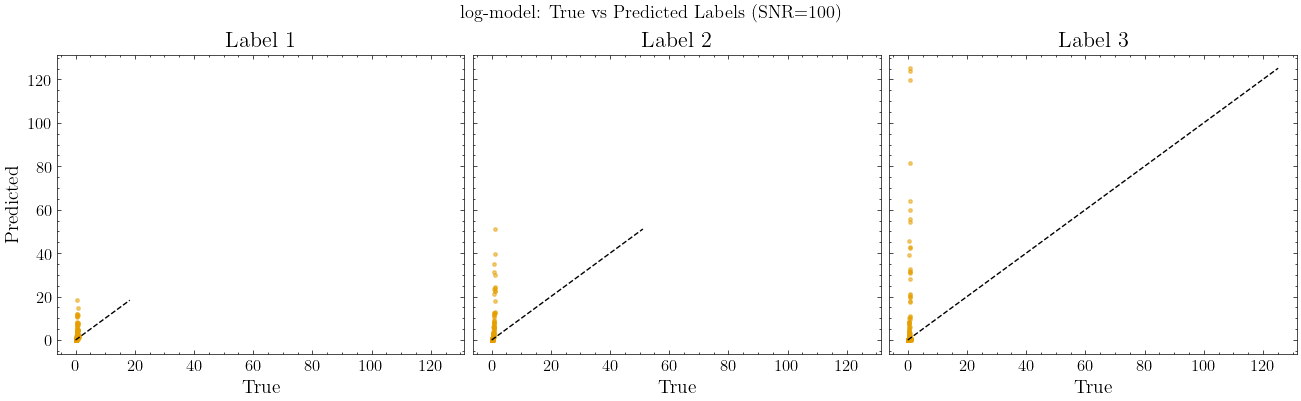

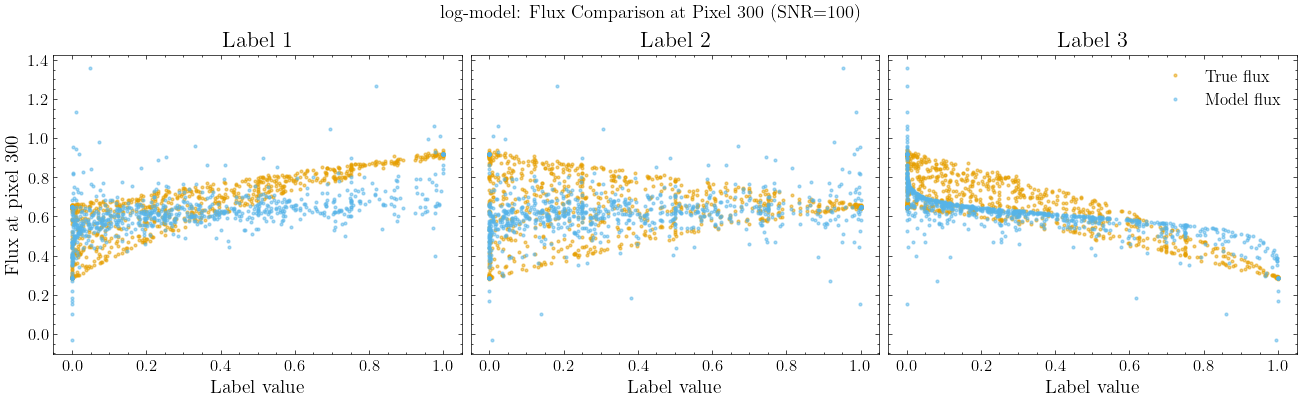


--- log-prior-model ---


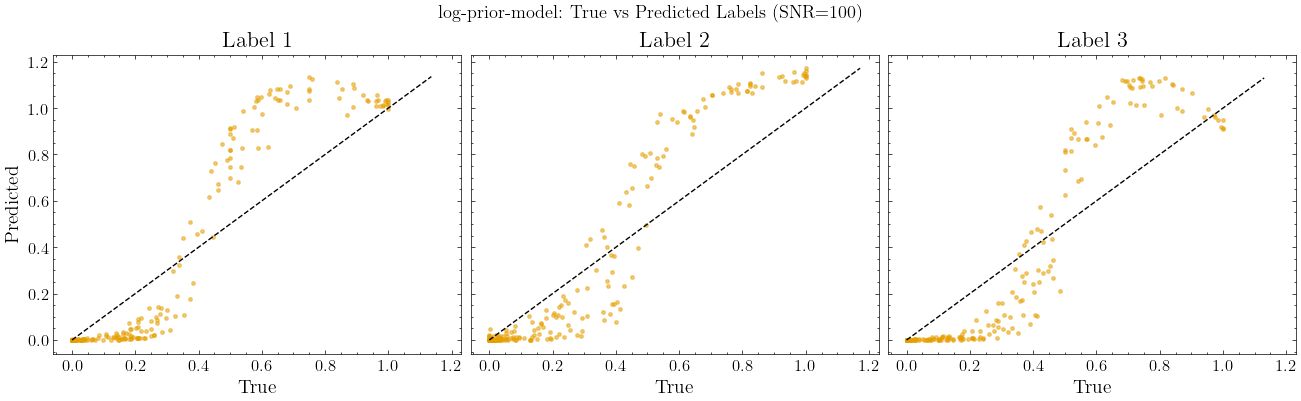

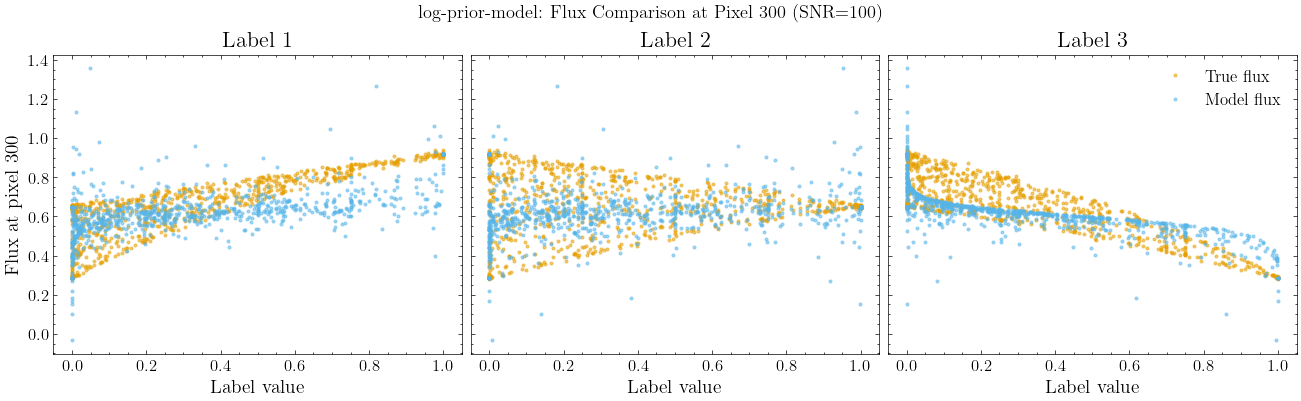


--- linear-model ---


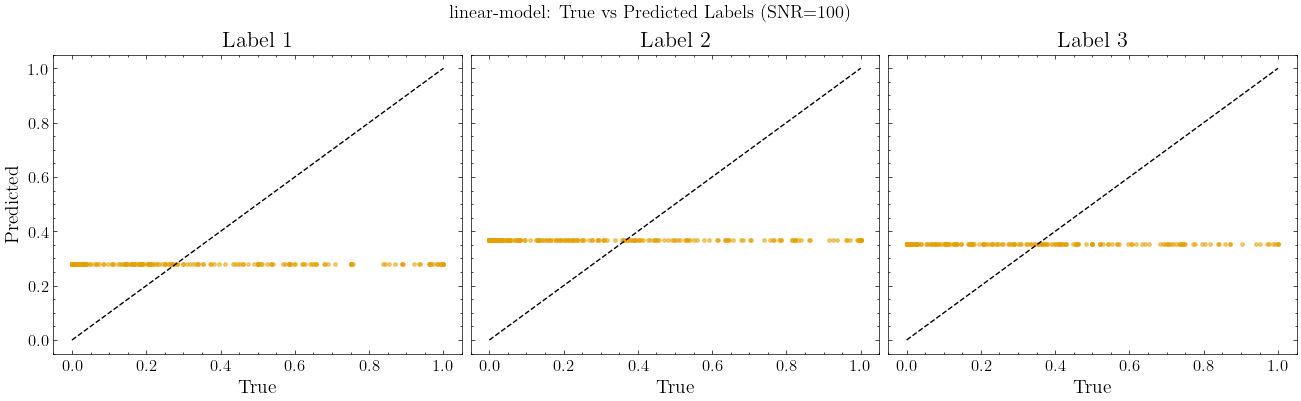

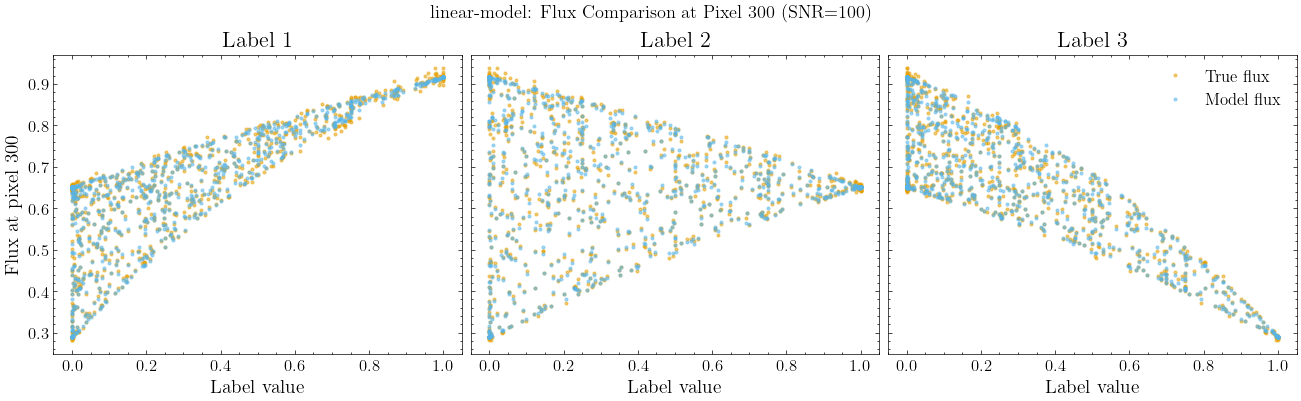


--- linear-prior-model ---


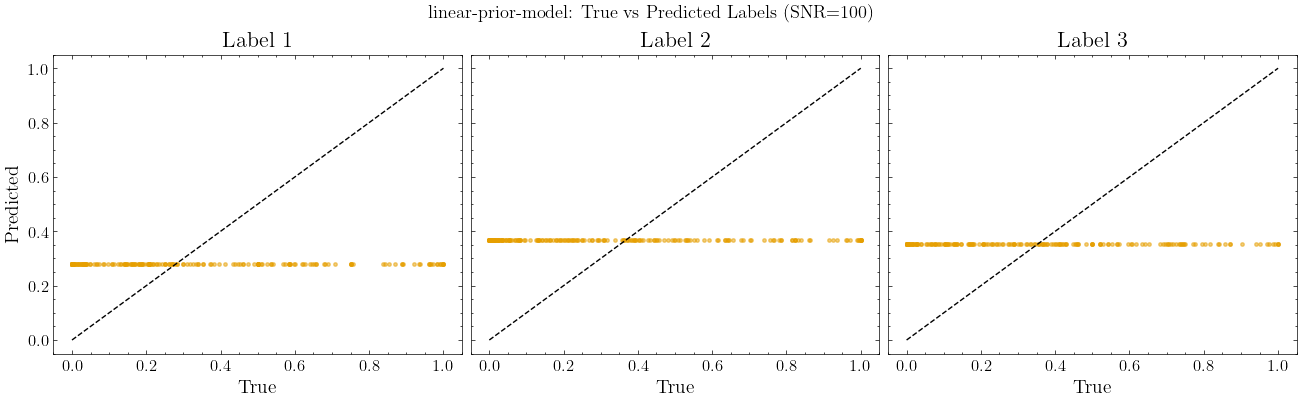

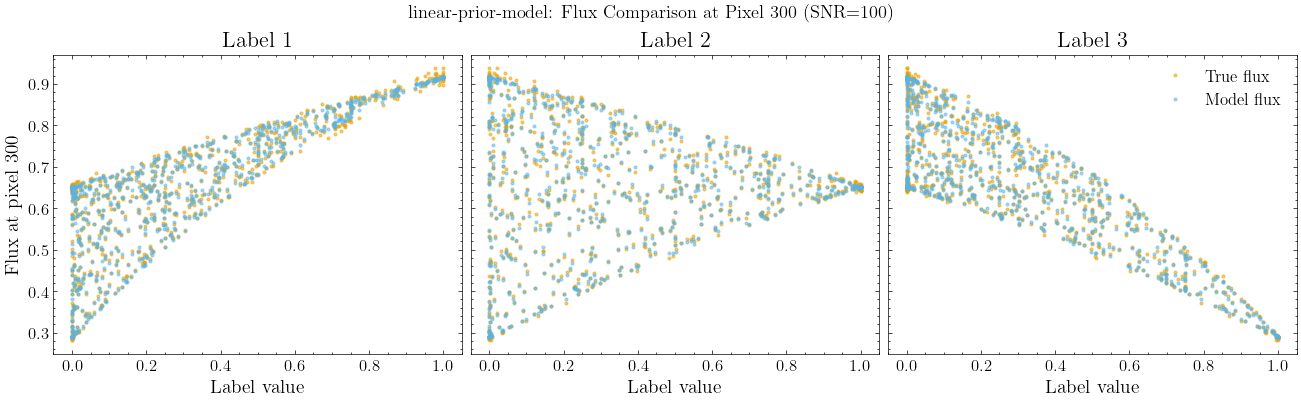

In [12]:
# Run this cell after setting run_name and folder names above.
for cfg_name in CONFIGS:
    print(f'\n--- {cfg_name} ---')
    plot_true_vs_pred(cfg_name, snr=default_snr)
    plot_flux_at_pixel(cfg_name, snr=default_snr, pixel=flux_pixel)

## Diagnostics: Why Labels Collapse

These cells help diagnose why linear bounded runs can collapse toward central label values.

1. Coefficient separability and conditioning of the linear label terms.
2. Inversion behavior on the model's own training spectra (where generalization is not the issue).

In [6]:
def diagnose_coefficients(config_name, snr=default_snr):
    """Report linear-term separability and conditioning for a model config."""
    model = load_model(config_name, snr=snr)

    # theta columns: [constant, linear terms..., quadratic/cross terms...]
    # For 3 labels, the 3 linear terms are columns 1..3.
    linear_theta = np.asarray(model.theta[:, 1:4], dtype=float)

    corr = np.corrcoef(linear_theta.T)
    gram = linear_theta.T @ linear_theta
    cond_gram = np.linalg.cond(gram)

    print(f"\n=== {config_name} | coefficient diagnostics ===")
    print("Linear-term correlation matrix:")
    print(np.array2string(corr, precision=3, suppress_small=True))
    print(f"cond(Theta_lin^T Theta_lin) = {cond_gram:.3e}")

    fig, ax = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, constrained_layout=True)
    for i in range(3):
        ax[i].plot(model.dispersion, linear_theta[:, i], linewidth=0.4, color='k')
        ax[i].set_title(f'{label_names[i]} linear coeff')
        ax[i].set_xlabel('Wavelength')
    ax[0].set_ylabel('Coefficient value')
    fig.suptitle(f'{config_name}: Linear Coefficient Vectors')
    plt.show()


=== log-model | coefficient diagnostics ===
Linear-term correlation matrix:
[[ 1.     0.759 -0.982]
 [ 0.759  1.    -0.817]
 [-0.982 -0.817  1.   ]]
cond(Theta_lin^T Theta_lin) = 1.860e+02


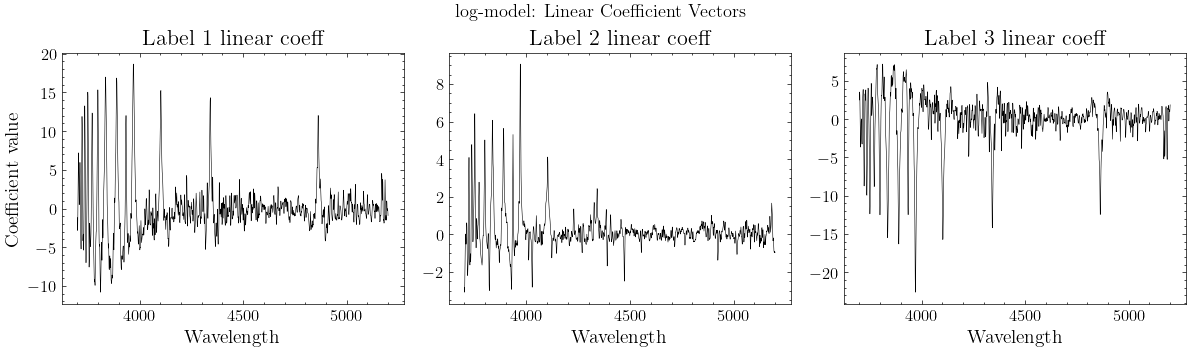

2026-03-24 11:25:12,969 [DEBUG] Couldn't get screen size. Progressbar may look odd.
stty: 'standard input': Inappropriate ioctl for device
2026-03-24 11:25:12,970 [INFO] Running test step on 800 spectra


[====================================================================================================] 100% (5s)                               

=== log-model | training inversion diagnostics ===
MAE per label: [2.4727 3.1391 7.8686]
Pred sum mean +/- std: 14.169313 +/- 2.526458e+01
Distance to center (1/3,1/3,1/3): mean=12.9369, std=23.8742


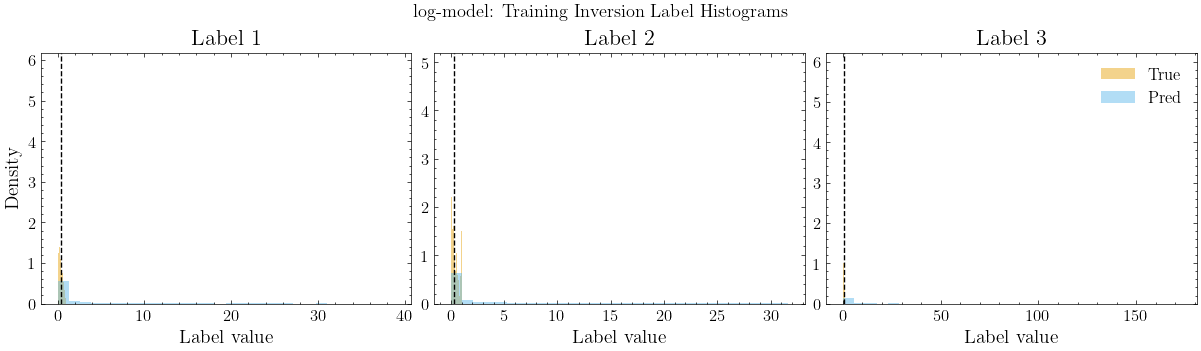


=== log-prior-model | coefficient diagnostics ===
Linear-term correlation matrix:
[[ 1.     0.759 -0.982]
 [ 0.759  1.    -0.817]
 [-0.982 -0.817  1.   ]]
cond(Theta_lin^T Theta_lin) = 1.860e+02


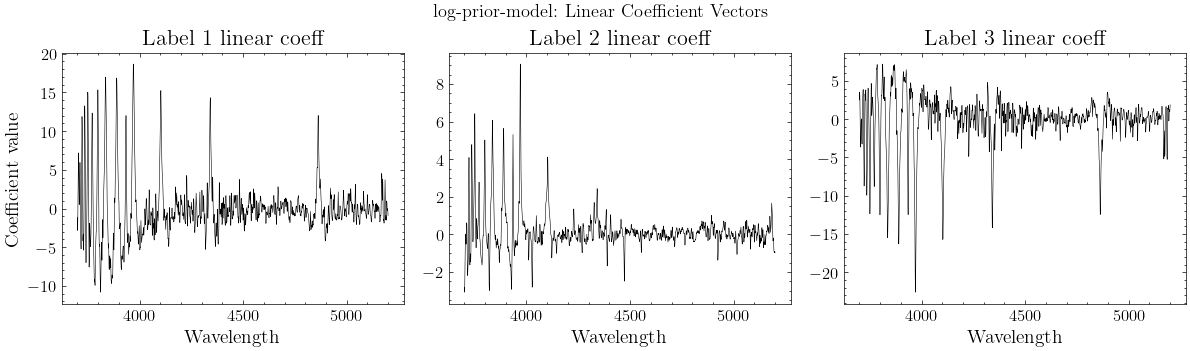

stty: 'standard input': Inappropriate ioctl for device2026-03-24 11:25:20,682 [DEBUG] Couldn't get screen size. Progressbar may look odd.

2026-03-24 11:25:20,683 [INFO] Running test step on 800 spectra


[====================================================================================================] 100% (6s)                               

=== log-prior-model | training inversion diagnostics ===
MAE per label: [ 61.5662  59.0084 133.5299]
Pred sum mean +/- std: 255.103868 +/- 4.646092e+02
Distance to center (1/3,1/3,1/3): mean=253.3354, std=465.2556


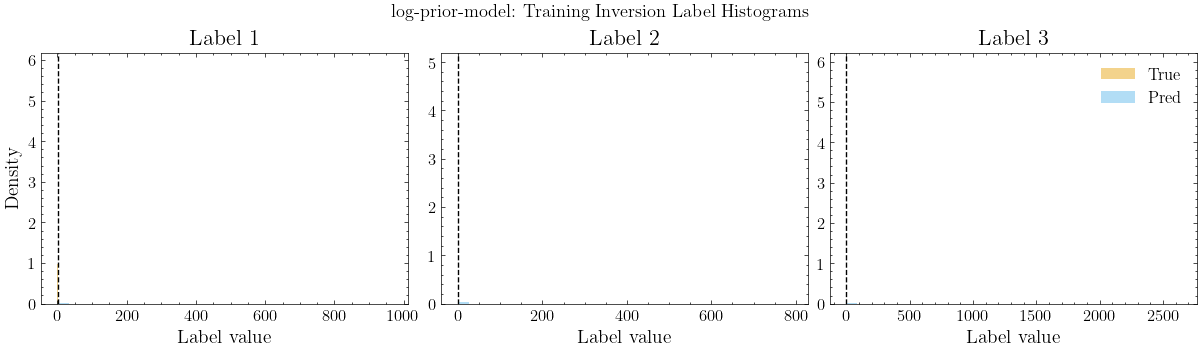


=== linear-model | coefficient diagnostics ===
Linear-term correlation matrix:
[[1.    0.895 0.895]
 [0.895 1.    1.   ]
 [0.895 1.    1.   ]]
cond(Theta_lin^T Theta_lin) = 4.998e+16


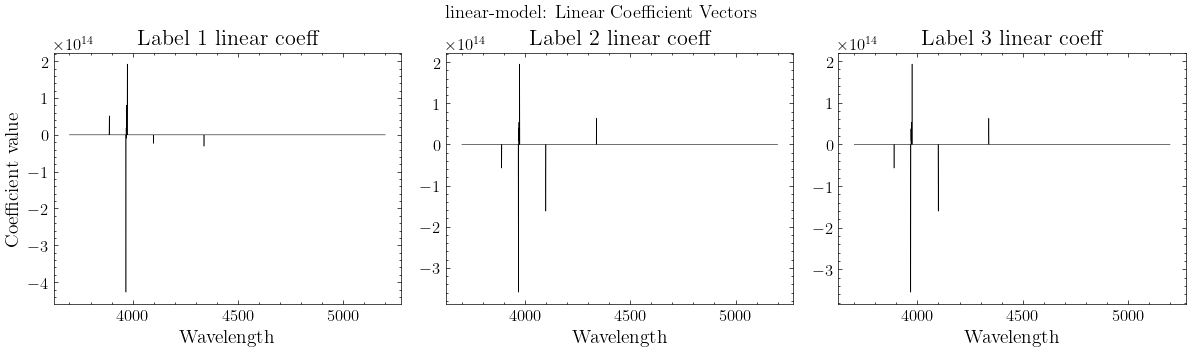

stty: 'standard input'2026-03-24 11:25:29,230 [DEBUG] Couldn't get screen size. Progressbar may look odd.
: Inappropriate ioctl for device
2026-03-24 11:25:29,231 [INFO] Running test step on 800 spectra


[====================================================================================================] 100% (8s)                               

=== linear-model | training inversion diagnostics ===
MAE per label: [0.244  0.2635 0.2517]
Pred sum mean +/- std: 1.000000 +/- 1.013698e-15
Distance to center (1/3,1/3,1/3): mean=0.0692, std=0.0001


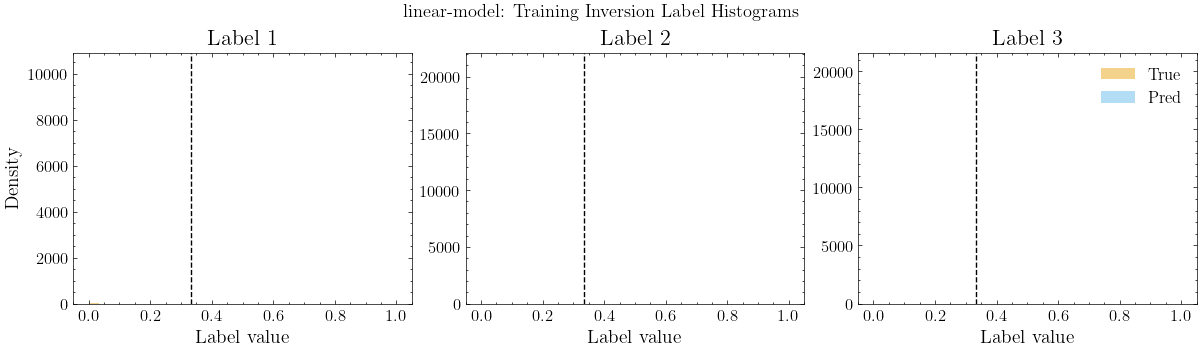


=== linear-prior-model | coefficient diagnostics ===
Linear-term correlation matrix:
[[1.    0.895 0.895]
 [0.895 1.    1.   ]
 [0.895 1.    1.   ]]
cond(Theta_lin^T Theta_lin) = 4.998e+16


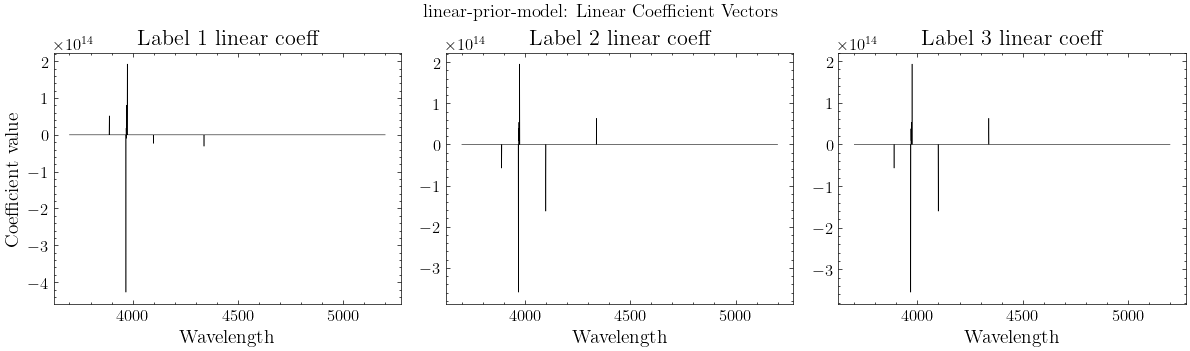

stty: 'standard input'2026-03-24 11:25:39,833 [DEBUG] Couldn't get screen size. Progressbar may look odd.
: Inappropriate ioctl for device
2026-03-24 11:25:39,834 [INFO] Running test step on 800 spectra


[====================================================================================================] 100% (16s)                              

=== linear-prior-model | training inversion diagnostics ===
MAE per label: [0.0049 0.0076 0.0037]
Pred sum mean +/- std: 1.000000 +/- 4.458206e-17
Distance to center (1/3,1/3,1/3): mean=0.4720, std=0.2052


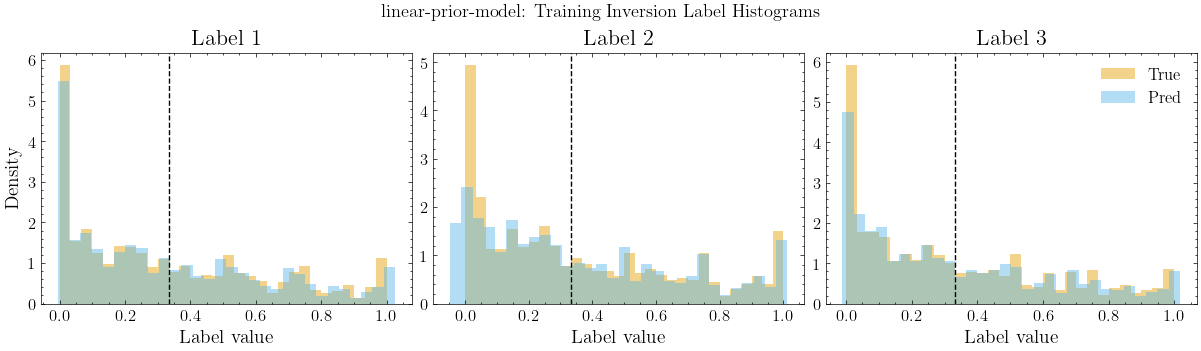

In [7]:
def diagnose_training_inversion(config_name, snr=default_snr, bins=30):
    """Run inversion on training spectra and check for center-collapse behavior."""
    cfg = CONFIGS[config_name]
    model = load_model(config_name, snr=snr)

    true_model_space = np.asarray(model.training_set_labels, dtype=float)
    flux = np.asarray(model.training_set_flux, dtype=float)
    ivar = np.asarray(model.training_set_ivar, dtype=float)

    # Use the same inverse constraints each config was trained/evaluated with.
    if config_name in ('linear-model', 'linear-bounds-model'):
        pred_model_space, *_ = model.test(flux, ivar, label_bounds=([0, 0, 0], [1, 1, 1]))
    elif config_name == 'log-prior-model':
        pred_model_space, *_ = model.test(flux, ivar, prior_sum_target=1, prior_sum_std=0.1)
    else:
        pred_model_space, *_ = model.test(flux, ivar)

    # Convert to linear label space for diagnostics.
    if cfg['model_labels_are_log10']:
        true_lin = np.power(10.0, true_model_space)
        pred_lin = np.power(10.0, pred_model_space)
    else:
        true_lin = true_model_space
        pred_lin = pred_model_space

    mae = np.mean(np.abs(pred_lin - true_lin), axis=0)
    sum_mean = np.mean(pred_lin.sum(axis=1))
    sum_std = np.std(pred_lin.sum(axis=1))
    center = np.array([1/3, 1/3, 1/3])
    center_dist = np.linalg.norm(pred_lin - center, axis=1)

    print(f"\n=== {config_name} | training inversion diagnostics ===")
    print(f"MAE per label: {np.array2string(mae, precision=4)}")
    print(f"Pred sum mean +/- std: {sum_mean:.6f} +/- {sum_std:.6e}")
    print(f"Distance to center (1/3,1/3,1/3): mean={center_dist.mean():.4f}, std={center_dist.std():.4f}")

    fig, ax = plt.subplots(1, 3, figsize=(12, 3.5), constrained_layout=True)
    for i in range(3):
        ax[i].hist(true_lin[:, i], bins=bins, alpha=0.45, density=True, label='True')
        ax[i].hist(pred_lin[:, i], bins=bins, alpha=0.45, density=True, label='Pred')
        ax[i].axvline(1/3, color='k', linestyle='--', linewidth=1)
        ax[i].set_title(label_names[i])
        ax[i].set_xlabel('Label value')
    ax[0].set_ylabel('Density')
    ax[-1].legend(loc='best')
    fig.suptitle(f'{config_name}: Training Inversion Label Histograms')
    plt.show()


# Run diagnostics for all configs
for cfg_name in CONFIGS:
    diagnose_coefficients(cfg_name, snr=default_snr)
    diagnose_training_inversion(cfg_name, snr=default_snr)

## Doing some comparisons for different three-label training set formulations with linear-bounds-prior model


Run: sfh_1000_3bins_20260323_155219



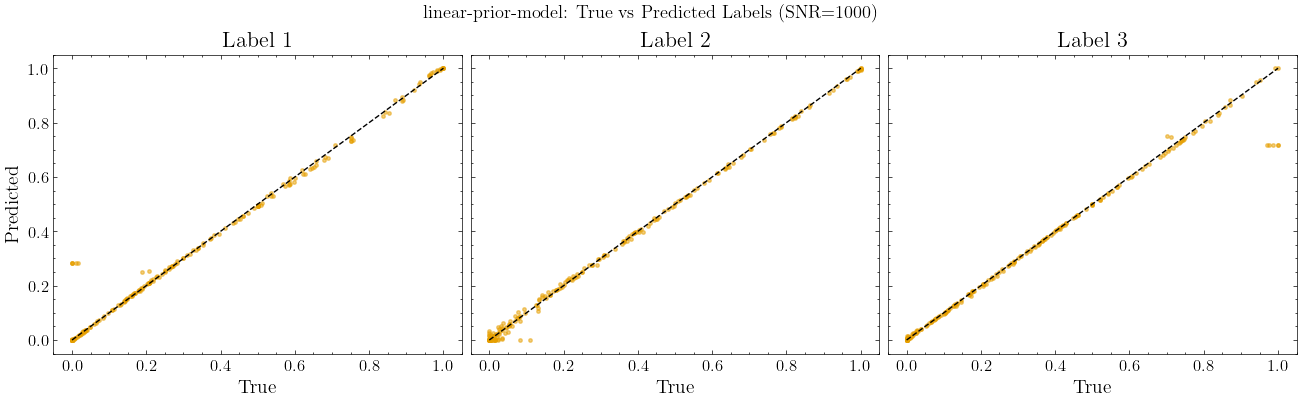

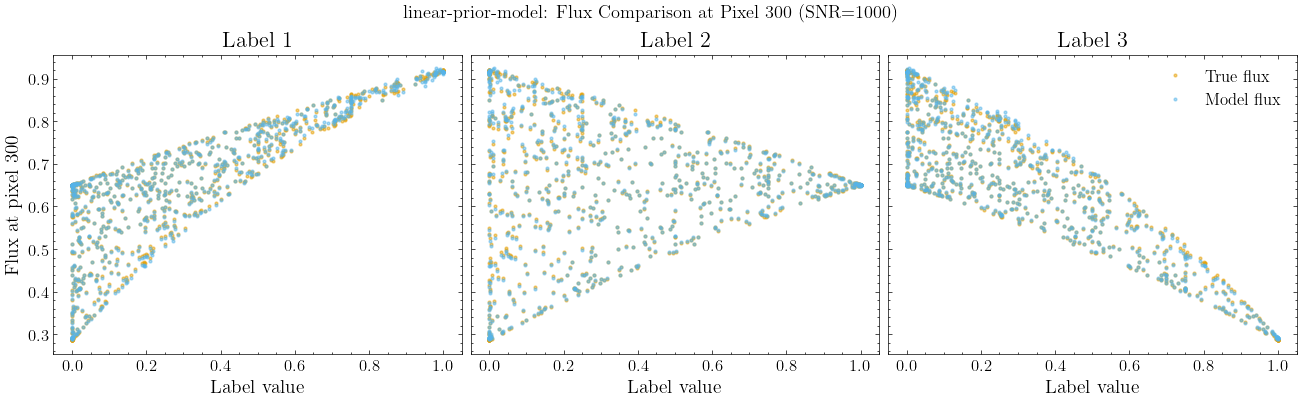


Run: sfh_1000_3bins_20260324_113613



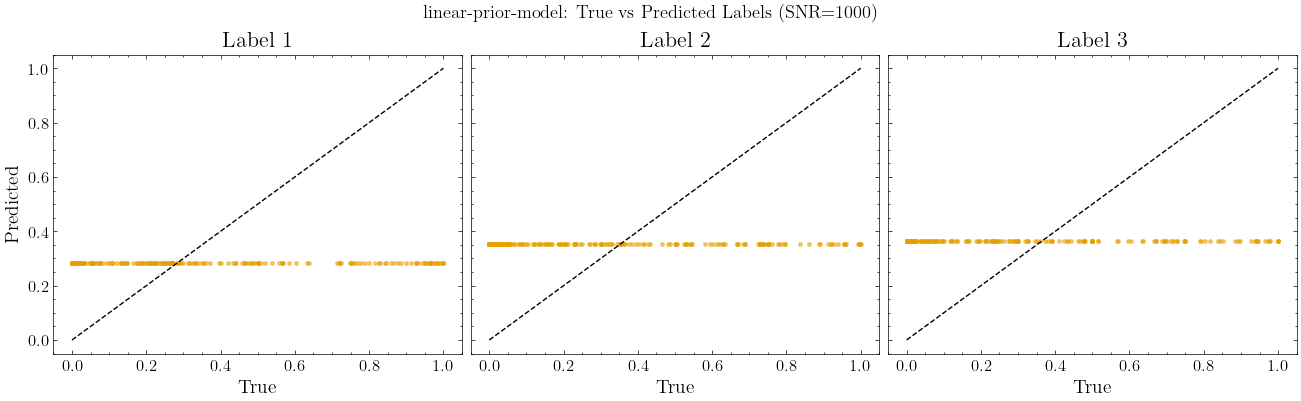

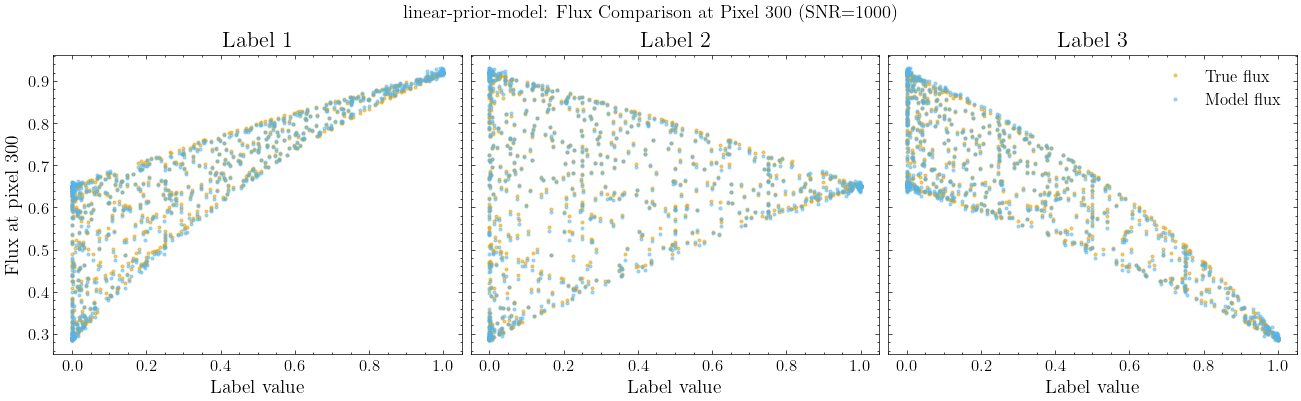


Run: sfh_1000_3bins_20260324_120434



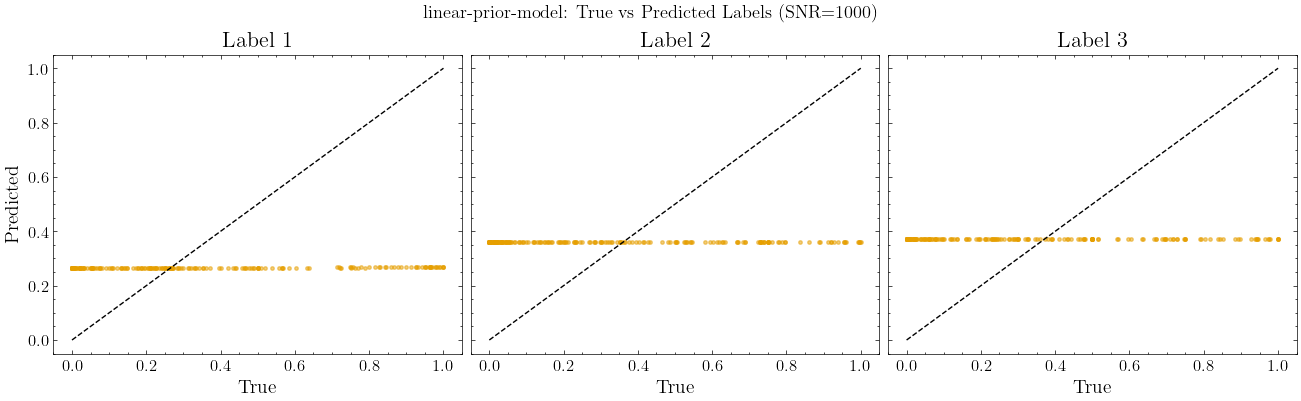

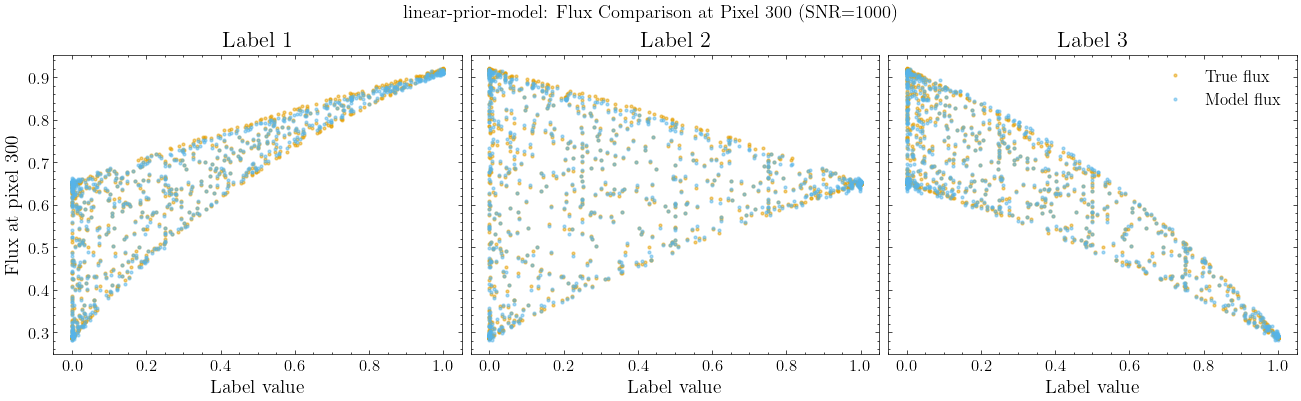


Run: sfh_1000_3bins_20260324_121020



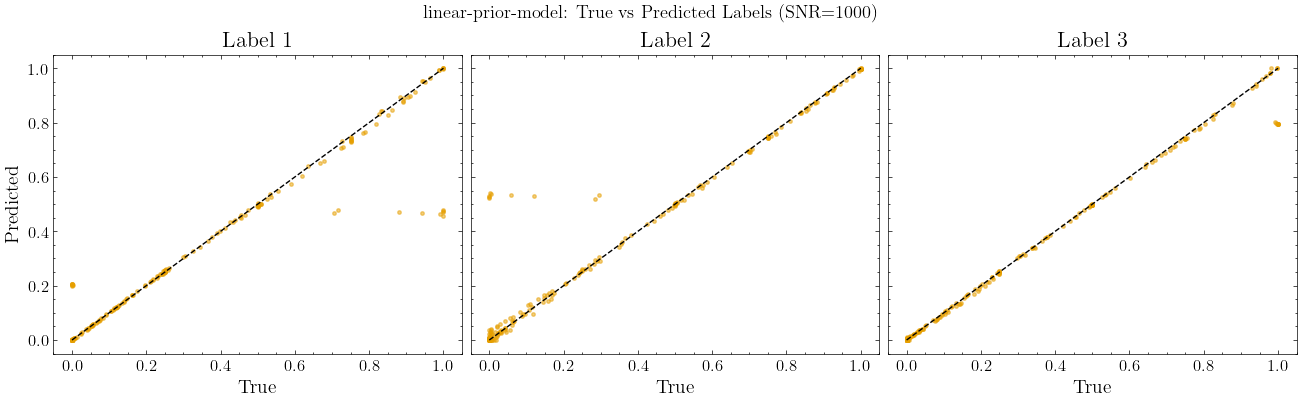

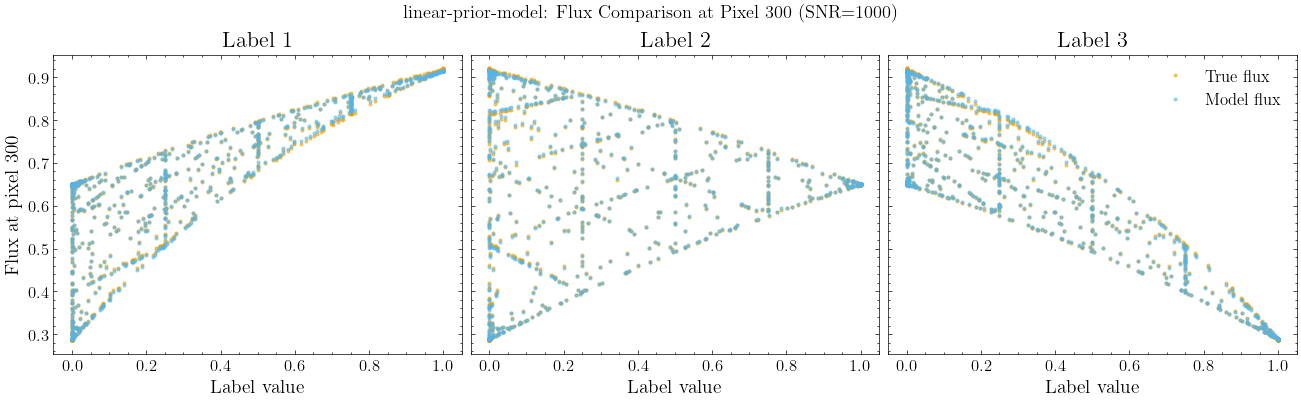

In [30]:
# List of run names to compare
run_names = [
    'sfh_1000_3bins_20260323_155219',
    'sfh_1000_3bins_20260324_113613',
    'sfh_1000_3bins_20260324_120434',
    'sfh_1000_3bins_20260324_121020',
    # Add more runs here
]

# Loop and plot for each run
for run_name in run_names:
    base_dir = Path('/avatar/vmehta') / run_name
    print(f"\n{'='*60}")
    print(f"Run: {run_name}")
    print(f"{'='*60}\n")
    plot_true_vs_pred('linear-prior-model', snr=default_snr)
    plot_flux_at_pixel('linear-prior-model', snr=default_snr, pixel=flux_pixel)

### Info about the different runs:

All of these runs are giving optimisation warnings on every single pixel.

**Run 1:**
- Mix ratios [0.4 0.4 0.2], alphas [1.0 0.25]
- Keeping a pretty even spread across the three labels

**Run 2:**
- Mix ratios [0.2 0.6 0.2], alphas [1.0 0.25]
- Pushing towards the extremes a little in an attempt to force the model to do something

**Run 3:**
- Kept mix ratios and alphas the same
- Modified base spectra slightly (moved int bin from 2 Gyr to 5 Gyr) but they still look very similar

**Run 4:**
- I'm about to give up
- Mix ratios [0 0.5 0.5], alphas [1.0 0.25]
- Tried this with both optimiser options, didn't help
- Also doesn't help to calculate derivatives on the fly
- WAIT BUT USING DOGBOX INSTEAD OF TRF GIVES SOME RESULTS OMG

In [20]:
file = 'sfh_1000_3bins_20260324_121020'

model_path = Path(f"/avatar/vmehta/{file}/linear-prior-model/snr1000_model.pkl")
model = CannonModel.read(str(model_path))

In [27]:
model.__dict__

{'_vectorizer': <AnniesLasso.thecannon.vectorizer.polynomial.PolynomialVectorizer object at 0x7f9cfdd029f0>,
 '_training_set_flux': array([[0.97808338, 0.99657371, 0.99243824, ..., 0.98574199, 0.98931406,
         0.9976824 ],
        [1.01213257, 1.03935785, 1.03179137, ..., 0.99879687, 1.00675153,
         1.0212513 ],
        [0.99307705, 1.01209434, 1.00823744, ..., 0.9901489 , 0.99726212,
         1.01119746],
        ...,
        [1.01197374, 1.0354605 , 1.03247299, ..., 0.99804127, 1.00779366,
         1.02111297],
        [0.99988508, 1.00227478, 1.00338122, ..., 0.99447566, 0.99438708,
         0.99719612],
        [0.99901709, 1.00312907, 1.00280056, ..., 0.99264822, 0.99598855,
         0.99801363]], shape=(800, 1667)),
 '_training_set_ivar': array([[1045985.38600479, 1010063.90597211, 1011764.67753215, ...,
         1031871.96117515, 1021345.94566084, 1001868.60497551],
        [ 977013.64272327,  925481.83778316,  935870.43047138, ...,
         1001979.08903739,  985679.46

In [9]:
path = Path("/avatar/vmehta/sfh_1000_3bins_20260328_162048")
lin_pred = np.load(Path(path) / "linear-model/snr1000_all_pred.npy")
lin_true = np.load(Path(path) / "linear-model/snr1000_all_true.npy")
log_pred = np.load(Path(path) / "log-model/snr1000_all_pred.npy")
log_true = np.load(Path(path) / "log-model/snr1000_all_true.npy")

In [10]:
lin_pred

array([[0.46828733, 0.47559817, 0.05611451],
       [0.24740633, 0.23068956, 0.52190411],
       [0.47146345, 0.03672264, 0.49181392],
       ...,
       [0.02772167, 0.67176245, 0.30051589],
       [0.19333469, 0.51170214, 0.29496317],
       [0.10983726, 0.578638  , 0.31152473]], shape=(1000, 3))

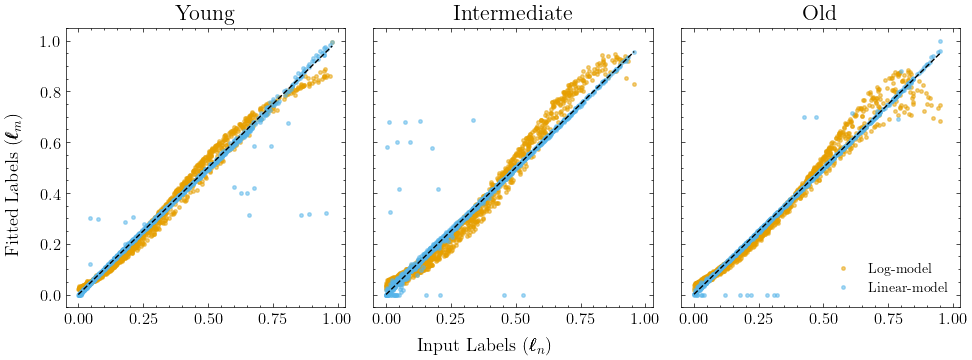

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(10,3.5), sharex=True, sharey=True)

for i in range(3):
    ax[i].plot(log_true[:, i], log_pred[:, i], '.', alpha=0.5, markersize=5)
    ax[i].plot(lin_true[:, i], lin_pred[:, i], '.', alpha=0.5, markersize=5)
    ax[i].plot([lin_true[:, i].min(), lin_true[:, i].max()], [lin_true[:, i].min(), lin_true[:, i].max()], 'k--', linewidth=1)
    ax[i].set_box_aspect(1)

ax[0].set_title('Young')
ax[1].set_title('Intermediate')
ax[2].set_title('Old')
ax[2].legend(['Log-model', 'Linear-model'], loc='lower right', fontsize=10)
fig.supxlabel(f'Input Labels ($\\pmb\\ell_n$)')
fig.supylabel(f'Fitted Labels ($\\pmb\\ell_m$)')

plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/logvslin.pdf', format='pdf')
plt.show()

## Testing training and fitting with fluxes in log-space

I note that model training is a lot slower with fluxes in log.

In [12]:
logflux_pred = np.load(Path(path) / "linear-model/log-flux/snr1000_all_pred.npy")
logflux_true = np.load(Path(path) / "linear-model/log-flux/snr1000_all_true.npy")
linflux_pred = np.load(Path(path) / "linear-model/linear-flux/snr1000_all_pred.npy")
linflux_true = np.load(Path(path) / "linear-model/linear-flux/snr1000_all_true.npy")

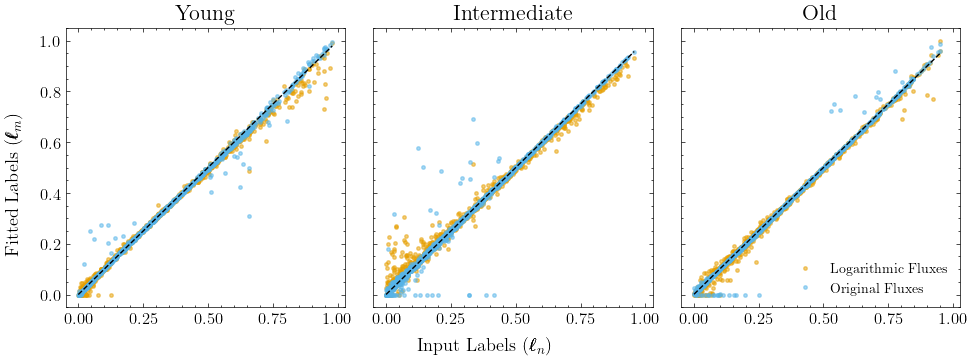

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(10,3.5), sharex=True, sharey=True)

for i in range(3):
    ax[i].plot(logflux_true[:, i], logflux_pred[:, i], '.', alpha=0.5, markersize=5)
    ax[i].plot(linflux_true[:, i], linflux_pred[:, i], '.', alpha=0.5, markersize=5)
    ax[i].plot([linflux_true[:, i].min(), linflux_true[:, i].max()], [linflux_true[:, i].min(), linflux_true[:, i].max()], 'k--', linewidth=1)
    ax[i].set_box_aspect(1)

ax[0].set_title('Young')
ax[1].set_title('Intermediate')
ax[2].set_title('Old')
ax[2].legend(['Logarithmic Fluxes', 'Original Fluxes'], loc='lower right', fontsize=10)
fig.supxlabel(f'Input Labels ($\\pmb\\ell_n$)')
fig.supylabel(f'Fitted Labels ($\\pmb\\ell_m$)')

plt.tight_layout()
#plt.savefig('/home/vmehta/honours-project/thesis/figures/logvslin.pdf', format='pdf')
plt.show()

In [15]:
for i in range(3):
    log_residuals = logflux_pred[:, i] - logflux_true[:, i]
    lin_residuals = linflux_pred[:, i] - linflux_true[:, i]
    print(f"Label {i+1}:")
    print(f"  Log-flux residuals: mean={log_residuals.mean():.4f}, std={log_residuals.std():.4f}")
    print(f"  Linear-flux residuals: mean={lin_residuals.mean():.4f}, std={lin_residuals.std():.4f}")
    print(np.percentile(log_residuals, 75) - np.percentile(log_residuals, 25))
    print(np.percentile(lin_residuals, 75) - np.percentile(lin_residuals, 25))

Label 1:
  Log-flux residuals: mean=-0.0032, std=0.0181
  Linear-flux residuals: mean=-0.0007, std=0.0214
0.010562961520088454
0.005141373567800669
Label 2:
  Log-flux residuals: mean=0.0053, std=0.0296
  Linear-flux residuals: mean=0.0014, std=0.0400
0.014528309419971346
0.00645318253076093
Label 3:
  Log-flux residuals: mean=-0.0021, std=0.0144
  Linear-flux residuals: mean=-0.0007, std=0.0205
0.007120278285703052
0.0026804017497437


In [12]:
from utils import *

bin_arr = [0.1, 100*10**6, 2*10**9, 10**10.15]
binning = np.log10(bin_arr)
bin_widths = np.diff(binning)
bin_centers = binning[:-1] + bin_widths/2

In [14]:
bin_centers

array([3.5     , 8.650515, 9.725515])

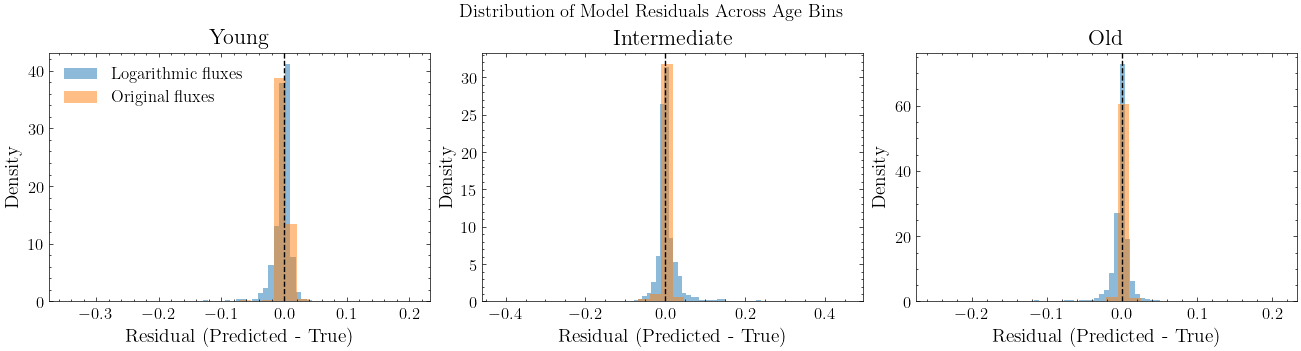

In [37]:
from matplotlib.patches import Patch

diff_log = logflux_pred - logflux_true
diff_lin = linflux_pred - linflux_true

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)

bin_labels = ['Young', 'Intermediate', 'Old']

for i in range(3):
    ax[i].hist(diff_log[:, i], bins=30, alpha=0.5, density=True, color='tab:blue', label='Logarithmic fluxes')
    ax[i].hist(diff_lin[:, i], bins=30, alpha=0.5, density=True, color='tab:orange', label='Original fluxes')
    ax[i].axvline(0, color='k', linestyle='--', linewidth=1)
    ax[i].set_title(bin_labels[i])
    ax[i].set_xlabel('Residual (Predicted - True)')
    ax[i].set_ylabel('Density')
    if i == 0:
        ax[i].legend(loc='best')

fig.suptitle('Distribution of Model Residuals Across Age Bins')
plt.show()

## The Final Three Label Model: Log-fluxes, Linear bound labels, sum prior

In [12]:
final_path = Path('/avatar/vmehta/sfh_1000_3bins_20260328_162048/linvslogforlogfluxes/linear-model')
fpred = np.load(final_path / "snr1000_all_pred.npy")
ftrue = np.load(final_path / "snr1000_all_true.npy")
basespec = np.load('/home/vmehta/honours-project/code/data/sfh_threebins_spectra.npy')
wavs = np.load('/home/vmehta/honours-project/code/data/wavelengths.npy')

In [28]:
def moving_average(x, w):
        """Returns the moving average of the input array."""
        return np.convolve(x, np.ones(w), 'same') / w

def normalize(v):
    s_flat = v / moving_average(v, 100)
    return s_flat * moving_average(np.ones_like(s_flat), 100) - 1  # dealing with edges

norm_vals = [normalize(v) for v in basespec]

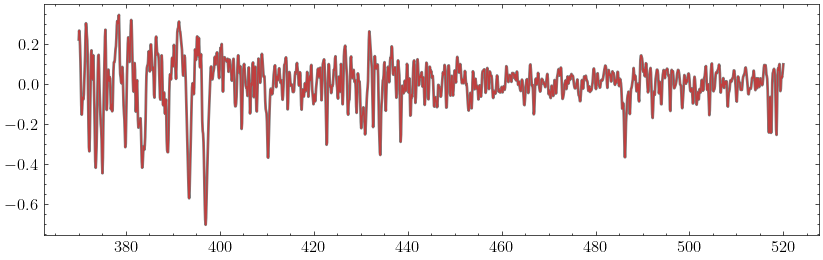

In [ ]:
n = 800
plt.figure(figsize=(10,3))
plt.plot(wavs/10, ftrue[n] @ norm_vals, 'k-', alpha=0.5, linewidth=2, label='True spectrum')
plt.plot(wavs/10, fpred[n] @ norm_vals, 'r-', alpha=0.5, linewidth=1, label='Predicted spectrum')
plt.